In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [9]:
df["Sex"] = df["Sex"].map({"male" :0,
                          "female":1
                          })

In [10]:
x = df[["Pclass","Age","Sex","Fare","SibSp","Parch"]]

In [11]:
y = df["Survived"]

In [12]:
x["Age"] = x["Age"].fillna(x["Age"].median())

C:\Users\Acer\AppData\Local\Temp\ipykernel_1532\3117338542.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Age"] = x["Age"].fillna(x["Age"].median())


In [13]:
x.isnull().sum()

Pclass    0
Age       0
Sex       0
Fare      0
SibSp     0
Parch     0
dtype: int64

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.linear_model import LogisticRegression
lg = LogisticRegression()
lg.fit(x_train,y_train)


LogisticRegression()

In [15]:
y_pred = lg.predict(x_test)

In [16]:
from sklearn.metrics import accuracy_score , confusion_matrix  , classification_report , precision_score , recall_score,f1_score

acc = accuracy_score(y_pred,y_test)
print("accuracy_score",acc)

cm = confusion_matrix(y_pred,y_test)
print("confusin_matrix",cm)

cr = classification_report(y_pred,y_test)
print("classification_report",cr)

pre = precision_score(y_pred,y_test)
print("precision_score",pre)

rc = recall_score(y_pred,y_test)
print("recall_score",rc)

f1 = f1_score(y_pred,y_test)
print("fi_score",f1)

accuracy_score 0.8100558659217877
confusin_matrix [[92 21]
 [13 53]]
classification_report               precision    recall  f1-score   support

           0       0.88      0.81      0.84       113
           1       0.72      0.80      0.76        66

    accuracy                           0.81       179
   macro avg       0.80      0.81      0.80       179
weighted avg       0.82      0.81      0.81       179

precision_score 0.7162162162162162
recall_score 0.803030303030303
fi_score 0.7571428571428571


In [17]:
probability = lg.predict_proba(x_test)

print(probability[:5])

[[0.9188624  0.0811376 ]
 [0.7628726  0.2371274 ]
 [0.85315502 0.14684498]
 [0.10152832 0.89847168]
 [0.32402922 0.67597078]]


In [18]:
new_passenger = pd.DataFrame([[1,25,1,100,0,0]],
                             columns = x.columns
                            )

In [19]:
prediction = lg.predict(new_passenger)
print("prediction",prediction)

prediction [1]


In [20]:
probability= lg.predict_proba(new_passenger)
print("probability",probability)

probability [[0.05384706 0.94615294]]


In [21]:
print("Coefficients",lg.coef_)
print("intercept",lg.intercept_)

Coefficients [[-0.92817595 -0.03144979  2.61055223  0.00343378 -0.31575981 -0.12520599]]
intercept [1.62674713]


In [22]:
print(x.columns)
print(lg.coef_[0])

Index(['Pclass', 'Age', 'Sex', 'Fare', 'SibSp', 'Parch'], dtype='object')
[-0.92817595 -0.03144979  2.61055223  0.00343378 -0.31575981 -0.12520599]


In [23]:
print("Logistic Regression Model") 
print("--------------------")
print("accurancy",acc)
print("prediction",prediction)
print("probability",probability)


Logistic Regression Model
--------------------
accurancy 0.8100558659217877
prediction [1]
probability [[0.05384706 0.94615294]]


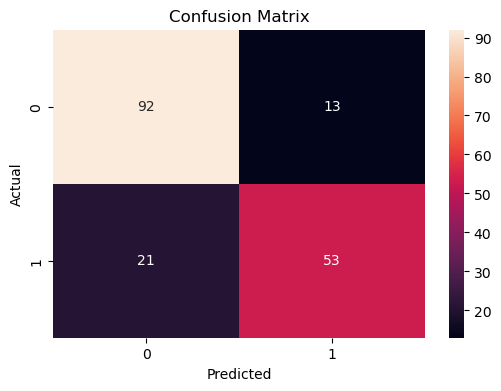

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

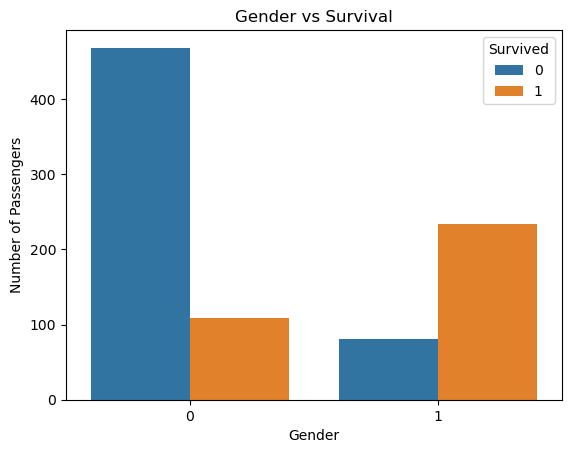

In [26]:
sns.countplot(x="Sex", hue="Survived", data=df)

plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.title("Gender vs Survival")
plt.show()